## Clustering and Initialization

In [1]:
import sys
import os

sys.path.append(os.path.abspath("script"))

In [2]:
from synthetic_data import generate_blobs
from plots import plot_synthetic_points, plot_kmeans_result, results_kmeans_kmeanspp, plot_iterations, plot_strip, plot_best_worst_comparison
from kmeans import Kmeans, KmeansPlusPlus
from benchmark_kmeans import benchmark_kmeans

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits, fetch_openml

#### Synthetic Datasets 

In [13]:
centers = [
    ( 0,  0),   
    (-8,  5),   
    ( 8,  4),   
    (-5, -7),   
    ( 6, -6)   
]

cluster_sizes = [120, 100, 110, 90, 100]

n_samples = 500     # total number of points 
std = 1.2           # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X, y = generate_blobs(centers=centers, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

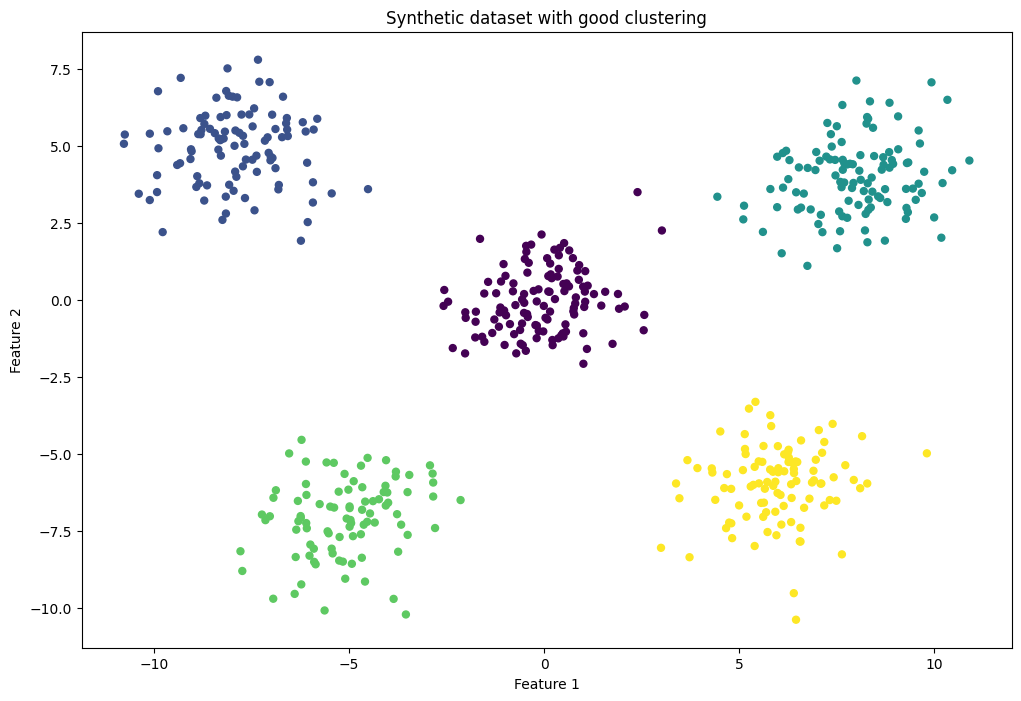

In [14]:
plot_synthetic_points(X, y, "Synthetic dataset with good clustering")

#### Real-world datasets

The MNIST dataset is a widely used benchmark in machine learning, consisting of 70000 grayscale images of handwritten digits (0–9), each represented as a 784-dimensional vector obtained by flattening 28 $\times$ 28 pixel images. 

From original dataset, i take a subset of 3000 examples, due to computational matters.

In [22]:
X_mnist, y_mnist = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

subset_size = 3000
random_state_mnist = 42

X_mnist = X_mnist.astype(np.float64) / 255.0
y_mnist = y_mnist.astype(int)

rng = np.random.default_rng(random_state_mnist)
idx = rng.choice(X_mnist.shape[0], size=subset_size, replace=False)

X_mnist = X_mnist[idx]
y_mnist = y_mnist[idx]

print("Shape X_MNIST =", X_mnist.shape)
print("Shape y_MNIST =", y_mnist.shape)

df_mnist = pd.DataFrame(X_mnist)
df_mnist["label"] = y_mnist

df_mnist

Shape X_MNIST = (3000, 784)
Shape y_MNIST = (3000,)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [23]:
df_mnist['label'].value_counts()

label
7    330
1    317
0    317
3    317
4    312
8    301
9    286
2    286
5    267
6    267
Name: count, dtype: int64

#### Run K-Means and K-means++

Multiple runs of Kmeans and Kmeans++ on synthetic dataset with good and balanced clusters.

In [4]:
# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans = []
n_iters_kmeans = []
labels_kmeans = []
centroids_kmeans = [] 

inertias_kmeanspp = []
n_iters_kmeanspp = []
labels_kmeanspp = []
centroids_kmeanspp = []

for seed in range(n_runs):
    # kmeans
    model_kmeans = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans.fit(X)

    inertias_kmeans.append(model_kmeans.inertia)
    n_iters_kmeans.append(model_kmeans.n_iter)
    labels_kmeans.append(model_kmeans.labels.copy())
    centroids_kmeans.append(model_kmeans.centroids.copy())

    # kmeans++
    model_kmeanspp = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp.fit(X)

    inertias_kmeanspp.append(model_kmeanspp.inertia)
    n_iters_kmeanspp.append(model_kmeanspp.n_iter)
    labels_kmeanspp.append(model_kmeanspp.labels.copy())
    centroids_kmeanspp.append(model_kmeanspp.centroids.copy())

inertias_kmeans = np.array(inertias_kmeans)
n_iters_kmeans = np.array(n_iters_kmeans)

inertias_kmeanspp = np.array(inertias_kmeanspp)
n_iters_kmeanspp = np.array(n_iters_kmeanspp)

Multiple runs of Kmeans and Kmeans++ on synthetic dataset with overlapped and balanced clusters.

In [11]:
# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans_overlap = []
n_iters_kmeans_overlap = []
labels_kmeans_overlap = []
centroids_kmeans_overlap = [] 

inertias_kmeanspp_overlap = []
n_iters_kmeanspp_overlap = []
labels_kmeanspp_overlap = []
centroids_kmeanspp_overlap = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_overlap = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_overlap.fit(X_overlap)

    inertias_kmeans_overlap.append(model_kmeans_overlap.inertia)
    n_iters_kmeans_overlap.append(model_kmeans_overlap.n_iter)
    labels_kmeans_overlap.append(model_kmeans_overlap.labels.copy())
    centroids_kmeans_overlap.append(model_kmeans_overlap.centroids.copy())

    # kmeans++
    model_kmeanspp_overlap = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_overlap.fit(X_overlap)

    inertias_kmeanspp_overlap.append(model_kmeanspp_overlap.inertia)
    n_iters_kmeanspp_overlap.append(model_kmeanspp_overlap.n_iter)
    labels_kmeanspp_overlap.append(model_kmeanspp_overlap.labels.copy())
    centroids_kmeanspp_overlap.append(model_kmeanspp_overlap.centroids.copy())

inertias_kmeans_overlap = np.array(inertias_kmeans_overlap)
n_iters_kmeans_overlap = np.array(n_iters_kmeans_overlap)

inertias_kmeanspp_overlap = np.array(inertias_kmeanspp_overlap)
n_iters_kmeanspp_overlap = np.array(n_iters_kmeanspp_overlap)

Multiple runs of Kmeans and Kmeans++ on synthetic dataset with good and imbalanced clusters.

In [25]:
# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans_imbalanced = []
n_iters_kmeans_imbalanced = []
labels_kmeans_imbalanced = []
centroids_kmeans_imbalanced = [] 

inertias_kmeanspp_imbalanced = []
n_iters_kmeanspp_imbalanced = []
labels_kmeanspp_imbalanced = []
centroids_kmeanspp_imbalanced = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_imbalanced = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_imbalanced.fit(X_imbalanced)

    inertias_kmeans_imbalanced.append(model_kmeans_imbalanced.inertia)
    n_iters_kmeans_imbalanced.append(model_kmeans_imbalanced.n_iter)
    labels_kmeans_imbalanced.append(model_kmeans_imbalanced.labels.copy())
    centroids_kmeans_imbalanced.append(model_kmeans_imbalanced.centroids.copy())

    # kmeans++
    model_kmeanspp_imbalanced = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp.fit(X_imbalanced)

    inertias_kmeanspp_imbalanced.append(model_kmeanspp_imbalanced.inertia)
    n_iters_kmeanspp_imbalanced.append(model_kmeanspp_imbalanced.n_iter)
    labels_kmeanspp_imbalanced.append(model_kmeanspp_imbalanced.labels.copy())
    centroids_kmeanspp_imbalanced.append(model_kmeanspp_imbalanced.centroids.copy())

inertias_kmeans_imbalanced = np.array(inertias_kmeans_imbalanced)
n_iters_kmeans_imbalanced = np.array(n_iters_kmeans_imbalanced)

inertias_kmeanspp_imbalanced = np.array(inertias_kmeanspp_imbalanced)
n_iters_kmeanspp_imbalanced = np.array(n_iters_kmeanspp_imbalanced)

AttributeError: 'NoneType' object has no attribute 'copy'

Multiple runs of Kmeans and Kmeans++ on synthetic dataset with overlapped and imbalanced clusters.

In [ ]:
#todo

Multiple runs of Kmeans and Kmeans++ on MNIST dataset.

In [23]:
# settings
n_clusters = 10
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_kmeans_mnist = []
n_iters_kmeans_mnist = []
labels_kmeans_mnist = []
centroids_kmeans_mnist = [] 

inertias_kmeanspp_mnist = []
n_iters_kmeanspp_mnist = []
labels_kmeanspp_mnist = []
centroids_kmeanspp_mnist = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_mnist = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_mnist.fit(X_mnist)

    inertias_kmeans_mnist.append(model_kmeans_mnist.inertia)
    n_iters_kmeans_mnist.append(model_kmeans_mnist.n_iter)
    labels_kmeans_mnist.append(model_kmeans_mnist.labels.copy())
    centroids_kmeans_mnist.append(model_kmeans_mnist.centroids.copy())

    # kmeans++
    model_kmeanspp_mnist = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_mnist.fit(X_mnist)

    inertias_kmeanspp_mnist.append(model_kmeanspp_mnist.inertia)
    n_iters_kmeanspp_mnist.append(model_kmeanspp_mnist.n_iter)
    labels_kmeanspp_mnist.append(model_kmeanspp_mnist.labels.copy())
    centroids_kmeanspp_mnist.append(model_kmeanspp_mnist.centroids.copy())

inertias_kmeans_mnist = np.array(inertias_kmeans_mnist)
n_iters_kmeans_mnist = np.array(n_iters_kmeans_mnist)

inertias_kmeanspp_mnist = np.array(inertias_kmeanspp_mnist)
n_iters_kmeanspp_mnist = np.array(n_iters_kmeanspp_mnist)

#### Results K-Means and K-means++ on synthetic dataset (well-separated)

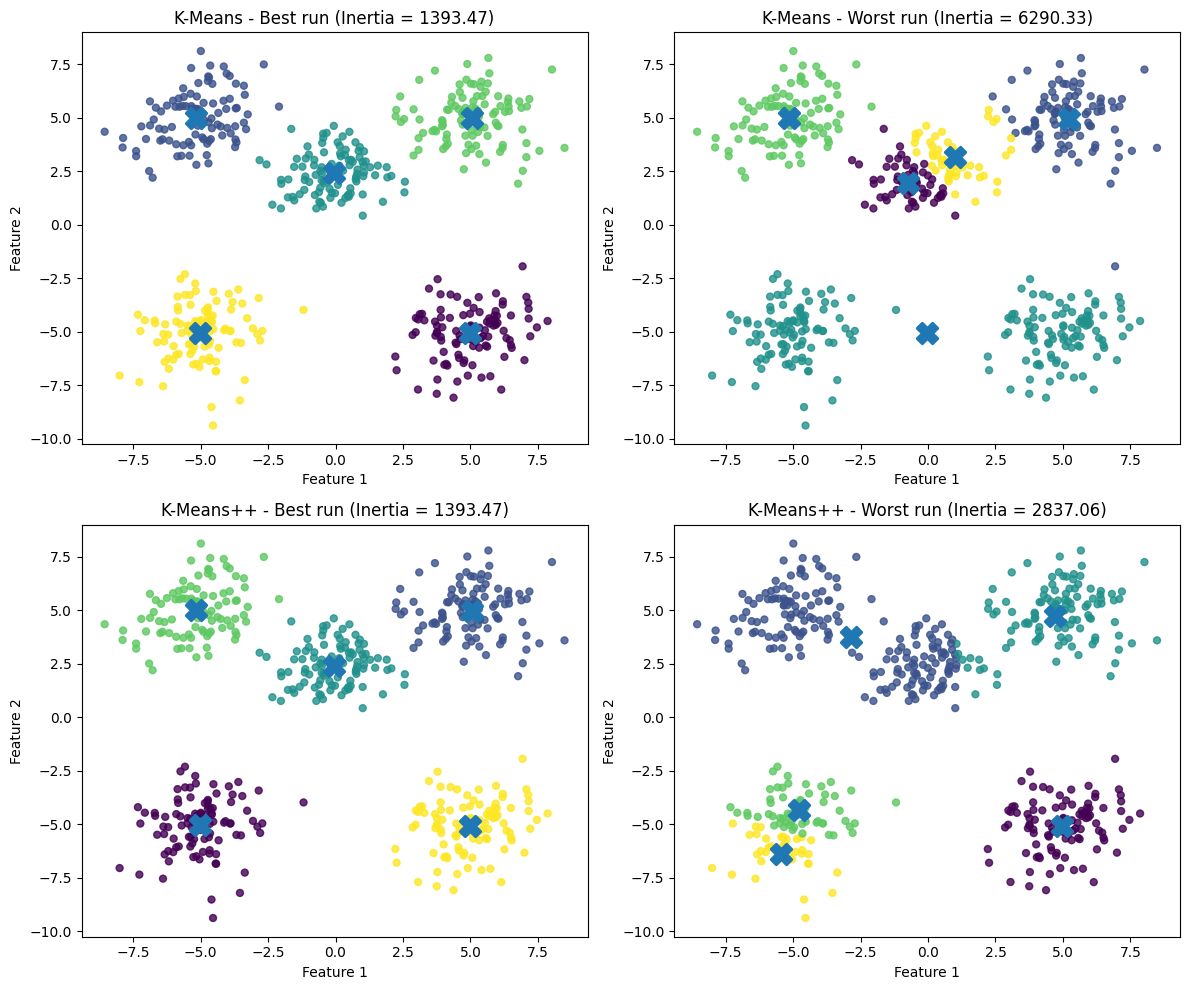

In [6]:
plot_best_worst_comparison(
    X,
    inertias_kmeans,
    labels_kmeans,
    centroids_kmeans,
    inertias_kmeanspp,
    labels_kmeanspp,
    centroids_kmeanspp
)

In [5]:
results_kmeans_kmeanspp(X,
                        inertias_kmeans,
                        n_iters_kmeans,
                        inertias_kmeanspp,
                        n_iters_kmeanspp)


K-Means
--------
Mean inertia    : 2145.9874
Std inertia     : 1233.4130
Min inertia     : 1393.4650
Max inertia     : 6290.3274
Mean iterations : 8.21

K-Means++
-----------
Mean inertia    : 1594.4637
Std inertia     : 498.1758
Min inertia     : 1393.4650
Max inertia     : 2837.0601
Mean iterations : 4.79


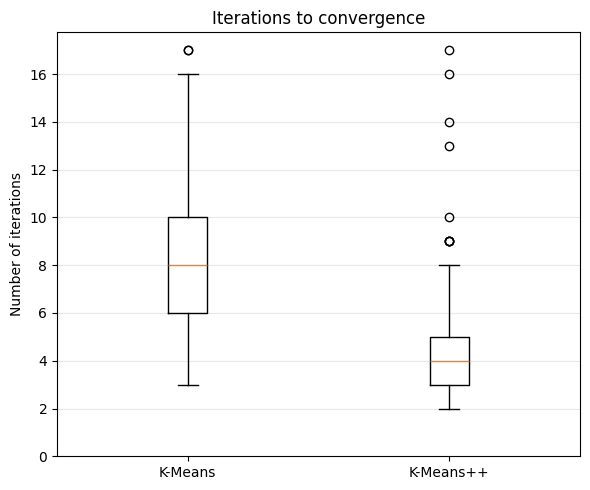

In [7]:
plot_iterations(n_iters_kmeans, n_iters_kmeanspp)

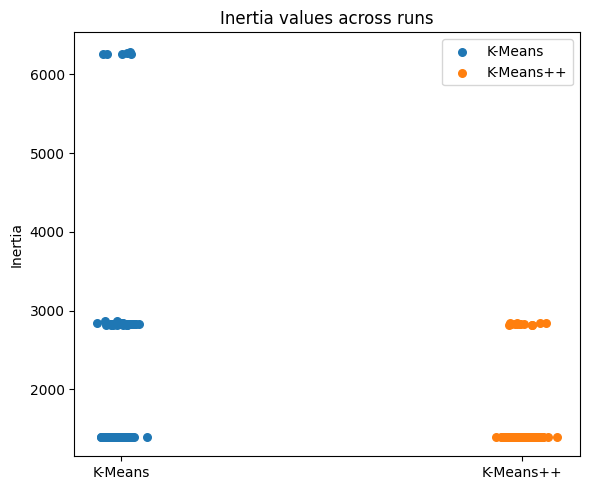

In [8]:
plot_strip(inertias_kmeans, inertias_kmeanspp)

#### Results K-Means and K-Means++ on synthetic dataset (overlapped)

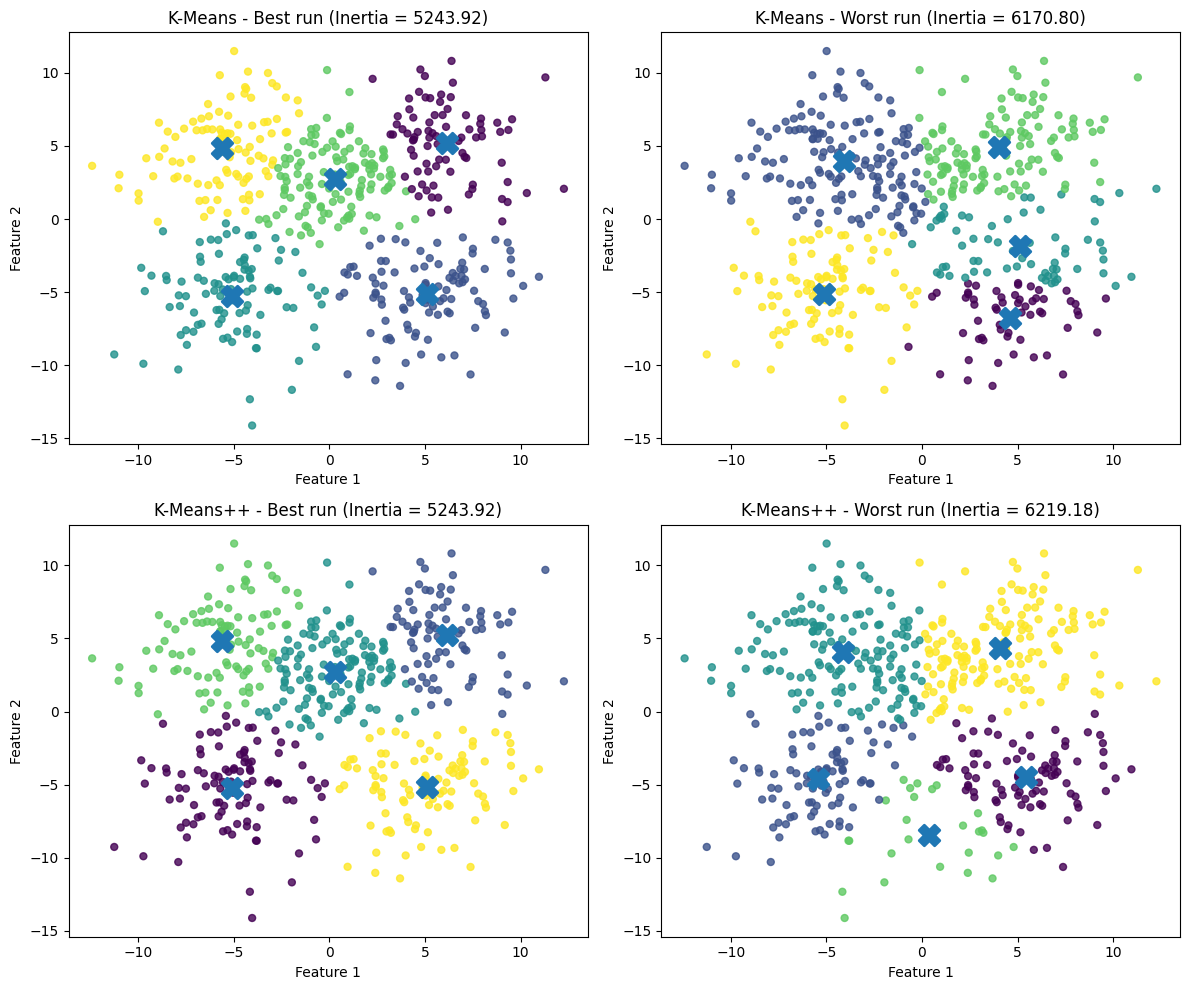

In [13]:
plot_best_worst_comparison(
    X_overlap,
    inertias_kmeans_overlap,
    labels_kmeans_overlap,
    centroids_kmeans_overlap,
    inertias_kmeanspp_overlap,
    labels_kmeanspp_overlap,
    centroids_kmeanspp_overlap
)

In [12]:
results_kmeans_kmeanspp(X_overlap,
                        inertias_kmeans_overlap,
                        n_iters_kmeans_overlap,
                        inertias_kmeanspp_overlap,
                        n_iters_kmeanspp_overlap)


K-Means
--------
Mean inertia    : 5364.5902
Std inertia     : 296.9117
Min inertia     : 5243.9217
Max inertia     : 6170.8025
Mean iterations : 16.92

K-Means++
-----------
Mean inertia    : 5399.3456
Std inertia     : 329.9077
Min inertia     : 5243.9217
Max inertia     : 6219.1828
Mean iterations : 15.52


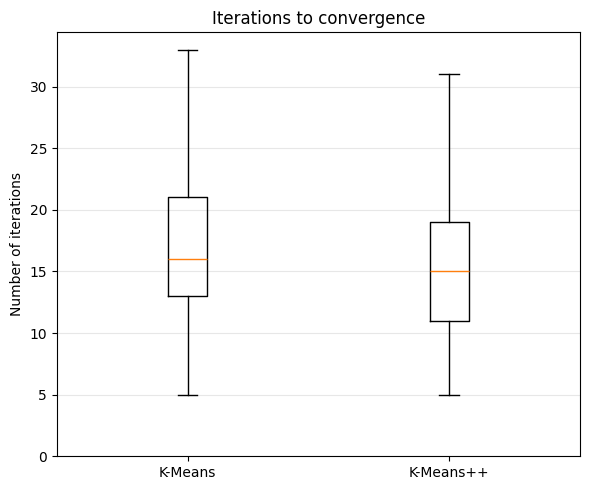

In [18]:
plot_iterations(n_iters_kmeans_overlap, n_iters_kmeanspp_overlap)

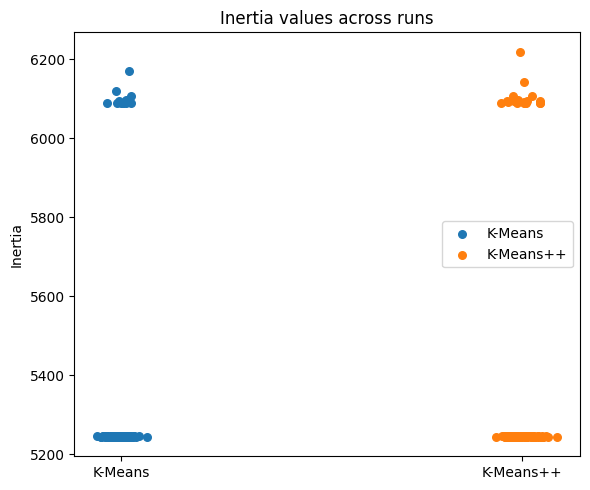

In [19]:
plot_strip(inertias_kmeans_overlap, inertias_kmeanspp_overlap)

#### Results K-Means and K-means++ on MNIST dataset    

In [ ]:
results_kmeans_kmeanspp(X_mnist,
                        inertias_kmeans_mnist,
                        n_iters_kmeans_mnist,
                        inertias_kmeanspp_mnist,
                        n_iters_kmeanspp_mnist)


K-Means
--------
Mean inertia    : 118535.0055
Std inertia     : 286.2635
Min inertia     : 118009.9615
Max inertia     : 119242.8549
Mean iterations : 40.18

K-Means++
-----------
Mean inertia    : 118629.7647
Std inertia     : 365.6151
Min inertia     : 118006.7044
Max inertia     : 119696.0676
Mean iterations : 34.14


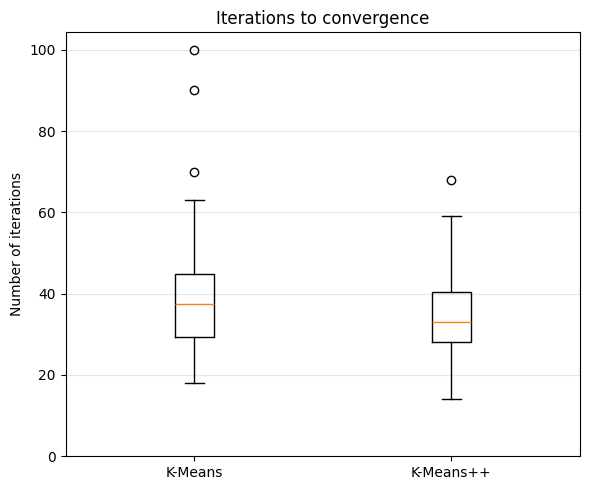

In [29]:
plot_iterations(n_iters_kmeans_mnist, n_iters_kmeanspp_mnist)

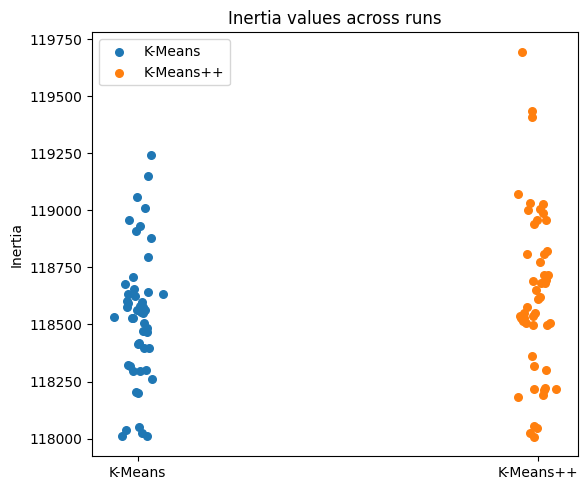

In [30]:
plot_strip(inertias_kmeans_mnist, inertias_kmeanspp_mnist)

#### Comparison with KMeans from scikit-learn library

In [20]:
benchmark_kmeans(X, 5)


Scikit-learn K-Means
--------------------
Mean inertia    : 2111.8478
Std inertia     : 1223.8062
Min inertia     : 1393.4650
Max inertia     : 7727.4344
Mean iterations : 7.56

Scikit-learn K-Means++
--------------------
Mean inertia    : 1508.1435
Std inertia     : 388.8968
Min inertia     : 1393.4650
Max inertia     : 2836.1355
Mean iterations : 3.76


In [21]:
benchmark_kmeans(X_overlap, 5)


Scikit-learn K-Means
--------------------
Mean inertia    : 5332.7011
Std inertia     : 263.8667
Min inertia     : 5243.9217
Max inertia     : 6219.9438
Mean iterations : 16.43

Scikit-learn K-Means++
--------------------
Mean inertia    : 5376.5440
Std inertia     : 313.9184
Min inertia     : 5243.9217
Max inertia     : 6248.3184
Mean iterations : 12.54


In [24]:
benchmark_kmeans(X_mnist, 10)


Scikit-learn K-Means
--------------------
Mean inertia    : 118607.5294
Std inertia     : 326.7794
Min inertia     : 118022.7364
Max inertia     : 119685.7386
Mean iterations : 34.54

Scikit-learn K-Means++
--------------------
Mean inertia    : 118644.2944
Std inertia     : 348.2988
Min inertia     : 118019.5014
Max inertia     : 119544.4475
Mean iterations : 36.29


#### Overlapping clusters

In [16]:
centers_overlapping = [
    (0.0, 0.0),    
    (2.5, 1.5),    
    (-2.0, 1.0),   
    (1.5, -2.5),   
    (-1.5, -2.0)   
]

cluster_sizes = [110, 95, 105, 100, 90]

n_samples = 500     # total number of points 
std = 1.6           # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X_overlapping, y_overlapping = generate_blobs(centers=centers_overlapping, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

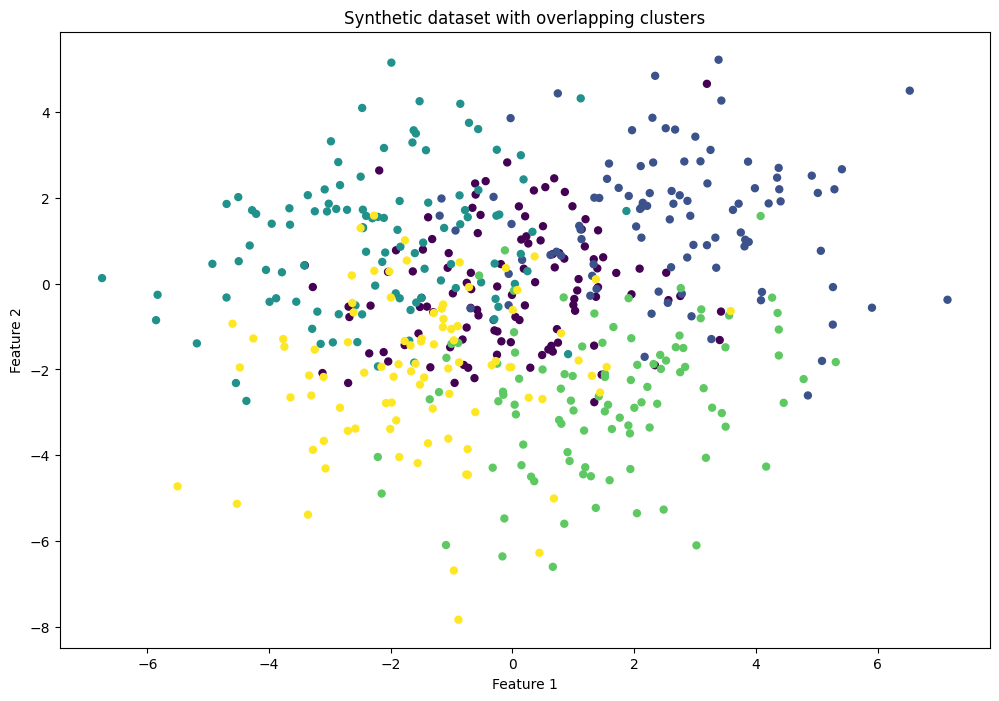

In [17]:
plot_synthetic_points(X_overlapping, y_overlapping, "Synthetic dataset with overlapping clusters")